# Ejercicio 4 - Analisis exploratorio con DuckDB (2026)

Cada pregunta tiene su consulta en `sql/04_eda/` y se ejecuta sobre la vista `trips_clean`
(definida en `sql/00_views.sql`, lee directamente los Parquet). DuckDB hace todas las agregaciones:
al notebook solo llegan tablas pequenas para graficar.

Preguntas (4.1):

| # | Pregunta | Dimension |
|---|---|---|
| 1 | Como evoluciona la cantidad de viajes mes a mes? | temporal |
| 2 | En que horas y dias se concentran los viajes? | temporal |
| 3 | Que tan largos y caros son los viajes tipicos? | caracteristicas |
| 4 | Como cambia la velocidad a lo largo del dia? | caracteristicas |
| 5 | Donde recogen pasajeros amarillos y verdes? | amarillo vs verde |
| 6 | Que metodos de pago se usan? | pago |
| 7 | Cuanta propina se deja con tarjeta y cuando? | pago |
| 8 | De que se compone el cobro? | pago / distribucion |
| 9 | Que peso tienen los viajes de aeropuerto? | caracteristicas / amarillo vs verde |
| 10 | Como se distribuye el total por viaje? | distribucion |
| 11 | Quedan atipicos en los datos limpios? | atipicos |
| 12 | Que proporcion de viajes se pide por apps de alto volumen? | pago / canal |

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "scripts"))

import matplotlib.pyplot as plt
import pandas as pd
from lab_db import DIR_SQL, connect, leer_consulta, run_query_file

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 200)
plt.rcParams.update({"figure.figsize": (10, 4), "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})
con = connect()   # conexion en memoria + vistas de sql/00_views.sql sobre los Parquet

In [2]:
COLOR = {"yellow": "#eda100", "green": "#008300"}   # paleta validada (amarillo/verde, ΔE CVD 16.2)
ETIQ = {"yellow": "Amarillos", "green": "Verdes"}
def q(nombre):
    df, seg = run_query_file(con, DIR_SQL / "04_eda" / nombre)
    return df

## 1. Viajes por mes

### `01_viajes_por_mes.sql`

- **Pregunta:** Como evoluciona la cantidad de viajes mes a mes y es igual la tendencia para amarillos y verdes?
- **Objetivo:** Comportamiento temporal mensual por tipo de taxi; indice relativo a enero para comparar escalas muy distintas.
- **Fuente:** vista trips_clean (Parquet de data/raw/*/*).

In [3]:
df, seg = run_query_file(con, DIR_SQL / "04_eda" / "01_viajes_por_mes.sql")
print(f"{seg:.2f} s, {len(df)} filas")
df

0.37 s, 16 filas


,taxi_type,anio,mes,viajes,indice_vs_enero,viajes_por_dia
0,green,2026,1,37755,100.0,1218.0
1,green,2026,2,34829,92.3,1244.0
2,green,2026,3,41350,109.5,1334.0
3,green,2026,4,41279,109.3,1376.0
4,green,2026,5,42023,111.3,1356.0
5,green,2026,6,41231,109.2,1374.0
6,green,2026,7,38241,101.3,1234.0
7,green,2026,8,37754,100.0,1218.0
8,yellow,2026,1,3504830,100.0,113059.0
9,yellow,2026,2,3199918,91.3,114283.0


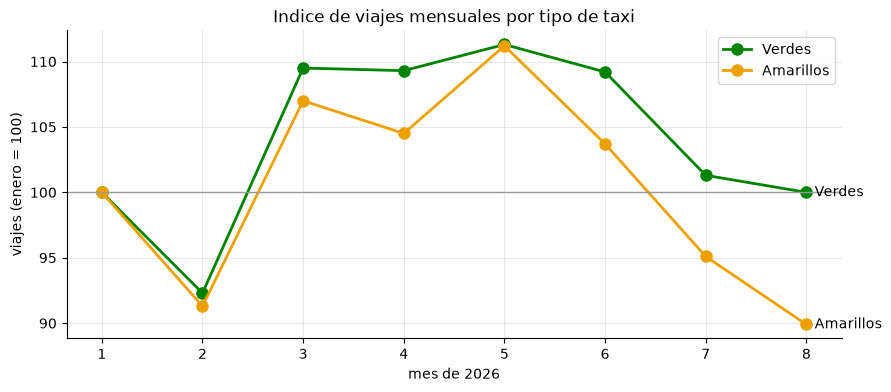

In [4]:
df = q("01_viajes_por_mes.sql")
fig, ax = plt.subplots()
for t, g in df.groupby("taxi_type"):
    ax.plot(g.mes, g.indice_vs_enero, color=COLOR[t], lw=2, marker="o", ms=8, label=ETIQ[t])
    ax.annotate(ETIQ[t], (g.mes.iloc[-1], g.indice_vs_enero.iloc[-1]), xytext=(6, 0), textcoords="offset points", va="center")
ax.axhline(100, color="#999", lw=1)
ax.set_xticks(range(1, 9)); ax.set_xlabel("mes de 2026"); ax.set_ylabel("viajes (enero = 100)")
ax.set_title("Indice de viajes mensuales por tipo de taxi"); ax.legend(); plt.show()

## 2. Hora del dia y dia de la semana

### `02_hora_y_dia.sql`

- **Pregunta:** En que horas y dias de la semana se concentran los viajes de cada tipo de taxi?
- **Objetivo:** Patron intradiario/semanal; porcentaje de los viajes de cada tipo que cae en cada combinacion dia-hora.
- **Fuente:** vista trips_clean.

In [5]:
df, seg = run_query_file(con, DIR_SQL / "04_eda" / "02_hora_y_dia.sql")
print(f"{seg:.2f} s, {len(df)} filas")
df

0.31 s, 336 filas


,taxi_type,dia_semana,hora,viajes,pct_del_tipo
0,green,1,0,466,0.148
1,green,1,1,221,0.070
2,green,1,2,130,0.041
3,green,1,3,94,0.030
4,green,1,4,168,0.053
...,...,...,...,...,...
331,yellow,7,19,187595,0.667
332,yellow,7,20,172960,0.615
333,yellow,7,21,169277,0.602
334,yellow,7,22,150293,0.534


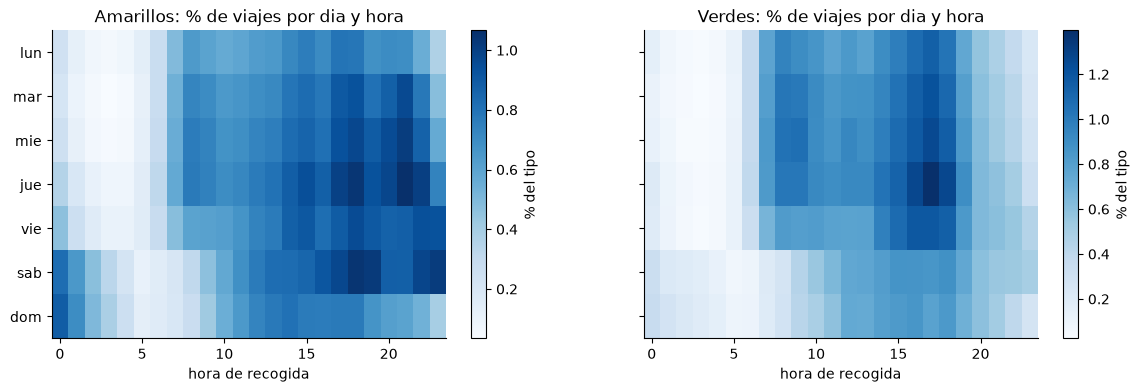

In [6]:
df = q("02_hora_y_dia.sql")
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
for ax, t in zip(axes, ["yellow", "green"]):
    m = df[df.taxi_type == t].pivot(index="dia_semana", columns="hora", values="pct_del_tipo")
    im = ax.imshow(m, aspect="auto", cmap="Blues")
    ax.set_title(f"{ETIQ[t]}: % de viajes por dia y hora"); ax.set_xlabel("hora de recogida")
    ax.set_yticks(range(7)); ax.set_yticklabels(["lun", "mar", "mie", "jue", "vie", "sab", "dom"])
    ax.grid(False); fig.colorbar(im, ax=ax, label="% del tipo")
plt.show()

## 3. Caracteristicas de los viajes

### `03_caracteristicas_viaje.sql`

- **Pregunta:** Que tan largos (distancia, duracion) y que tan caros son los viajes tipicos de cada tipo de taxi?
- **Objetivo:** Caracteristicas de los viajes con medianas y percentiles (robustos a valores extremos).
- **Fuente:** vista trips_clean.

In [7]:
df, seg = run_query_file(con, DIR_SQL / "04_eda" / "03_caracteristicas_viaje.sql")
print(f"{seg:.2f} s, {len(df)} filas")
df

4.24 s, 2 filas


,taxi_type,viajes,distancia_mediana_mi,distancia_p90_mi,duracion_mediana_min,duracion_p90_min,velocidad_mediana_mph,total_mediano_usd,pasajeros_promedio
0,green,314462,2.14,7.36,13.3,32.0,10.0,20.50,1.30
1,yellow,28134580,1.94,8.70,14.1,33.5,9.3,23.58,1.25


## 4. Velocidad por hora (lunes a viernes)

### `04_velocidad_por_hora.sql`

- **Pregunta:** Como cambia la velocidad promedio de los viajes a lo largo del dia (congestion)?
- **Objetivo:** Relacion entre hora del dia y velocidad mediana en dias laborales.
- **Fuente:** vista trips_clean, solo lunes a viernes.

In [8]:
df, seg = run_query_file(con, DIR_SQL / "04_eda" / "04_velocidad_por_hora.sql")
print(f"{seg:.2f} s, {len(df)} filas")
df

0.49 s, 48 filas


,taxi_type,hora,viajes,velocidad_mediana_mph,duracion_mediana_min
0,green,0,2469,12.6,10.9
1,green,1,1270,12.6,10.5
2,green,2,723,14.4,11.6
3,green,3,493,14.7,11.2
4,green,4,763,18.4,16.4
5,green,5,1787,16.0,14.9
6,green,6,5730,12.6,10.9
7,green,7,12289,10.2,12.8
8,green,8,15271,9.1,14.4
9,green,9,15092,9.4,14.3


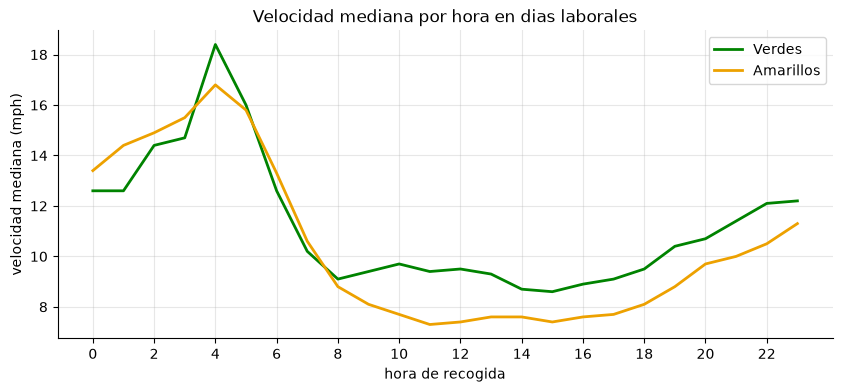

In [9]:
df = q("04_velocidad_por_hora.sql")
fig, ax = plt.subplots()
for t, g in df.groupby("taxi_type"):
    ax.plot(g.hora, g.velocidad_mediana_mph, color=COLOR[t], lw=2, label=ETIQ[t])
ax.set_xlabel("hora de recogida"); ax.set_ylabel("velocidad mediana (mph)"); ax.set_xticks(range(0, 24, 2))
ax.set_title("Velocidad mediana por hora en dias laborales"); ax.legend(); plt.show()

## 5. Borough de origen

### `05_zonas_por_tipo.sql`

- **Pregunta:** Donde recogen pasajeros los taxis amarillos y los verdes (borough de origen)?
- **Objetivo:** Comparar la cobertura geografica de cada tipo; los verdes (Boro Taxis) no pueden recoger en el sur de Manhattan ni aeropuertos.
- **Fuente:** vista trips_clean + vista zones (taxi_zone_lookup.csv).

In [10]:
df, seg = run_query_file(con, DIR_SQL / "04_eda" / "05_zonas_por_tipo.sql")
print(f"{seg:.2f} s, {len(df)} filas")
df

0.35 s, 15 filas


,taxi_type,borough_origen,viajes,pct_del_tipo
0,green,Manhattan,189325,60.21
1,green,Queens,68859,21.90
2,green,Brooklyn,48756,15.50
3,green,Bronx,7038,2.24
4,green,Unknown,286,0.09
5,green,N/A,153,0.05
6,green,Staten Island,45,0.01
7,yellow,Manhattan,24407187,86.75
8,yellow,Queens,2461388,8.75
9,yellow,Brooklyn,1012402,3.60


## 6. Metodo de pago

### `06_metodo_de_pago.sql`

- **Pregunta:** Que metodos de pago usan los pasajeros de cada tipo de taxi?
- **Objetivo:** Participacion de cada payment_type; incluye los registros sin informacion (Flex Fare / no informado).
- **Fuente:** vista trips_clean.

In [11]:
df, seg = run_query_file(con, DIR_SQL / "04_eda" / "06_metodo_de_pago.sql")
print(f"{seg:.2f} s, {len(df)} filas")
df

0.85 s, 10 filas


,taxi_type,metodo_pago,viajes,pct_del_tipo,total_mediano_usd
0,green,Tarjeta,209572,66.64,20.94
1,green,Efectivo,61562,19.58,16.10
2,green,Nulo,42652,13.56,26.61
3,green,Sin cargo,478,0.15,12.90
4,green,Disputa,198,0.06,11.20
5,yellow,Tarjeta,18408818,65.43,22.35
6,yellow,Flex Fare,7030490,24.99,28.99
7,yellow,Efectivo,2529366,8.99,18.55
8,yellow,Disputa,112572,0.40,18.95
9,yellow,Sin cargo,53334,0.19,16.85


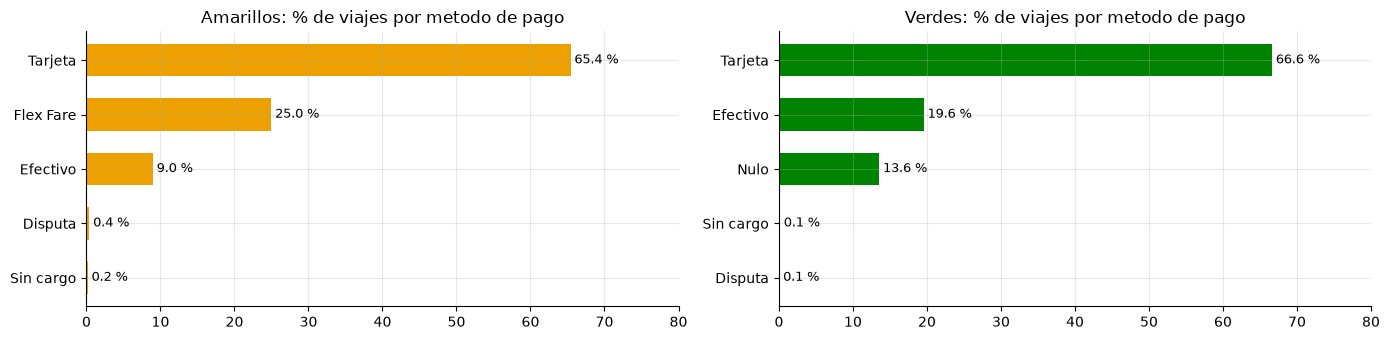

In [12]:
df = q("06_metodo_de_pago.sql")
fig, axes = plt.subplots(1, 2, figsize=(14, 3.5))
for ax, t in zip(axes, ["yellow", "green"]):
    g = df[df.taxi_type == t].sort_values("pct_del_tipo")
    ax.barh(g.metodo_pago, g.pct_del_tipo, color=COLOR[t], height=0.6)
    for y, v in enumerate(g.pct_del_tipo):
        ax.text(v + 0.5, y, f"{v:.1f} %", va="center", fontsize=9)
    ax.set_title(f"{ETIQ[t]}: % de viajes por metodo de pago"); ax.set_xlim(0, 80)
plt.tight_layout(); plt.show()

## 7. Propinas con tarjeta

### `07_propinas.sql`

- **Pregunta:** Cuanto dejan de propina los pasajeros que pagan con tarjeta y cambia segun la hora o el tipo de taxi?
- **Objetivo:** Porcentaje de propina sobre la tarifa en pagos con tarjeta (en efectivo la propina no se registra).
- **Fuente:** vista trips_clean, payment_type = 1 (tarjeta).

In [13]:
df, seg = run_query_file(con, DIR_SQL / "04_eda" / "07_propinas.sql")
print(f"{seg:.2f} s, {len(df)} filas")
df

0.64 s, 10 filas


,taxi_type,franja,viajes_tarjeta,propina_pct_promedio,propina_pct_mediana,pct_sin_propina
0,green,1 manana (6-9),35470,22.10,22.96,7.98
1,green,2 dia (10-15),68650,22.57,23.23,7.43
2,green,3 tarde (16-19),64504,24.07,25.45,7.64
3,green,4 noche (20-23),32144,22.73,23.91,9.73
4,green,5 madrugada (0-5),8804,21.35,22.21,16.03
5,yellow,1 manana (6-9),2203384,23.00,25.44,13.08
6,yellow,2 dia (10-15),6076623,24.41,25.70,9.00
7,yellow,3 tarde (16-19),5057498,26.60,27.85,7.21
8,yellow,4 noche (20-23),3802212,25.69,26.99,6.73
9,yellow,5 madrugada (0-5),1269101,24.03,26.24,13.68


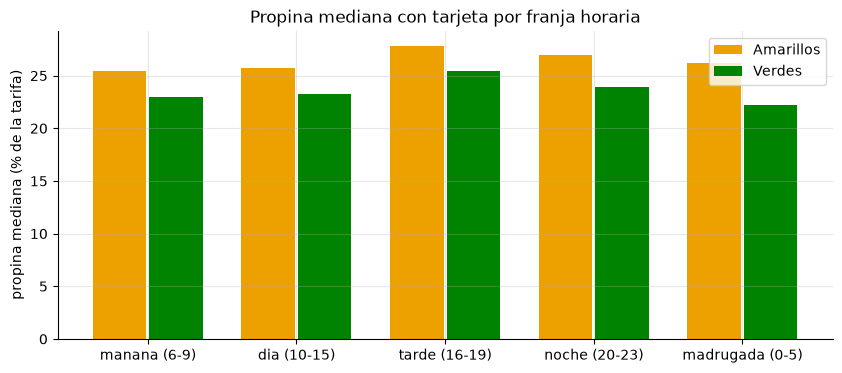

In [14]:
df = q("07_propinas.sql")
fig, ax = plt.subplots()
franjas = sorted(df.franja.unique()); x = range(len(franjas)); w = 0.38
for i, t in enumerate(["yellow", "green"]):
    g = df[df.taxi_type == t].set_index("franja").loc[franjas]
    ax.bar([p + (i - 0.5) * w for p in x], g.propina_pct_mediana, width=w - 0.02, color=COLOR[t], label=ETIQ[t])
ax.set_xticks(list(x)); ax.set_xticklabels([f[2:] for f in franjas])
ax.set_ylabel("propina mediana (% de la tarifa)"); ax.set_title("Propina mediana con tarjeta por franja horaria")
ax.legend(); plt.show()

## 8. Componentes del cobro

### `08_componentes_del_cobro.sql`

- **Pregunta:** De que se compone lo que paga un pasajero (tarifa, propina, recargos, peajes, cargo de congestion)?
- **Objetivo:** Participacion de cada componente en la facturacion total por tipo de taxi.
- **Fuente:** vista trips_clean.

In [15]:
df, seg = run_query_file(con, DIR_SQL / "04_eda" / "08_componentes_del_cobro.sql")
print(f"{seg:.2f} s, {len(df)} filas")
df

0.42 s, 2 filas


,taxi_type,facturacion_millones_usd,pct_tarifa,pct_propina,pct_peajes,pct_recargo_congestion,pct_cargo_cbd,pct_aeropuerto,pct_otros
0,green,7.96,66.89,10.44,1.17,3.15,0.25,0.00,9.26
1,yellow,849.28,70.37,9.53,1.83,5.62,1.80,0.42,8.74


## 9. Viajes de aeropuerto

### `09_aeropuertos.sql`

- **Pregunta:** Que peso tienen los viajes a/desde aeropuertos y en que se diferencian del resto?
- **Objetivo:** Comparar volumen, distancia y cobro de viajes de aeropuerto (zona JFK, LaGuardia o Newark en origen o destino).
- **Fuente:** vista trips_clean + vista zones.

In [16]:
df, seg = run_query_file(con, DIR_SQL / "04_eda" / "09_aeropuertos.sql")
print(f"{seg:.2f} s, {len(df)} filas")
df

1.60 s, 4 filas


,taxi_type,segmento,viajes,pct_viajes,pct_facturacion,distancia_mediana_mi,total_mediano_usd
0,green,aeropuerto,10734,3.41,6.53,6.47,40.00
1,green,resto,303728,96.59,93.47,2.07,20.07
2,yellow,aeropuerto,2280751,8.11,20.94,11.57,78.33
3,yellow,resto,25853829,91.89,79.06,1.78,22.45


## 10. Distribucion del total cobrado

### `10_distribucion_tarifa.sql`

- **Pregunta:** Como se distribuye el total cobrado por viaje y que tan pesada es la cola de viajes caros?
- **Objetivo:** Histograma del total cobrado en intervalos de 5 USD (hasta 150) por tipo de taxi.
- **Fuente:** vista trips_clean.

In [17]:
df, seg = run_query_file(con, DIR_SQL / "04_eda" / "10_distribucion_tarifa.sql")
print(f"{seg:.2f} s, {len(df)} filas")
df

0.31 s, 62 filas


,taxi_type,desde_usd,viajes,pct_del_tipo
0,green,0.0,44,0.014
1,green,5.0,15361,4.885
2,green,10.0,60486,19.235
3,green,15.0,74827,23.795
4,green,20.0,52045,16.550
...,...,...,...,...
57,yellow,130.0,12588,0.045
58,yellow,135.0,10509,0.037
59,yellow,140.0,8592,0.031
60,yellow,145.0,7392,0.026


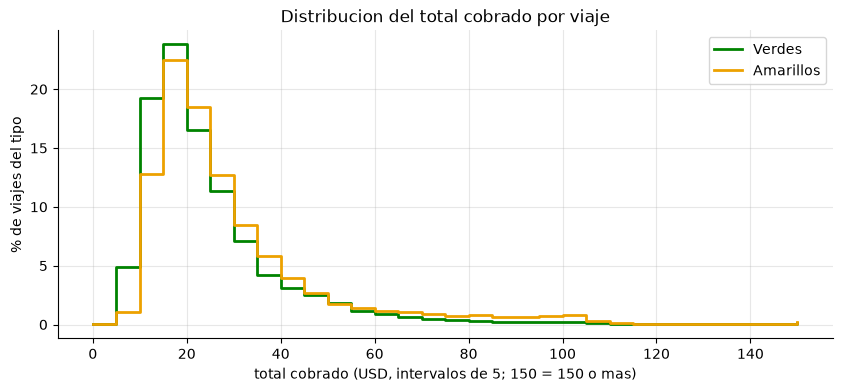

In [18]:
df = q("10_distribucion_tarifa.sql")
fig, ax = plt.subplots()
for t, g in df.groupby("taxi_type"):
    ax.step(g.desde_usd, g.pct_del_tipo, where="post", color=COLOR[t], lw=2, label=ETIQ[t])
ax.set_xlabel("total cobrado (USD, intervalos de 5; 150 = 150 o mas)"); ax.set_ylabel("% de viajes del tipo")
ax.set_title("Distribucion del total cobrado por viaje"); ax.legend(); plt.show()

## 11. Valores atipicos

### `11_atipicos.sql`

- **Pregunta:** Quedan valores atipicos dentro de los datos ya limpios (velocidades imposibles, tarifas por milla extremas)?
- **Objetivo:** Detectar outliers con la regla de Tukey (fuera de Q1 - 3*IQR / Q3 + 3*IQR) y con limites fisicos.
- **Fuente:** vista trips_clean.

In [19]:
df, seg = run_query_file(con, DIR_SQL / "04_eda" / "11_atipicos.sql")
print(f"{seg:.2f} s, {len(df)} filas")
df

1.86 s, 2 filas


,taxi_type,viajes,velocidad_mayor_65mph,pct_velocidad_imposible,q1_usd_milla,q3_usd_milla,limite_sup_usd_milla,atipicos_usd_milla,pct_atipicos_usd_milla
0,green,314462,111,0.035,5.42,8.17,16.42,6076,1.93
1,yellow,28134580,5890,0.021,5.73,9.91,22.47,678972,2.41


## 12. Viajes solicitados por apps de alto volumen

### `12_viajes_por_app.sql`

- **Pregunta:** Que proporcion de los viajes de taxi se solicitan a traves de plataformas de alto volumen (Uber/Lyft) desde que existe el dato?
- **Objetivo:** Participacion de request_source en los meses en que la columna existe.
- **Fuente:** vista trips_clean, meses con request_source informado.

In [20]:
df, seg = run_query_file(con, DIR_SQL / "04_eda" / "12_viajes_por_app.sql")
print(f"{seg:.2f} s, {len(df)} filas")
df

0.31 s, 6 filas


,taxi_type,anio,mes,viajes,pct_uber_hv0003,pct_lyft_hv0005,pct_otras_apps,pct_sin_dato
0,green,2026,6,41231,0.00,0.00,13.62,86.38
1,green,2026,7,38241,0.00,0.00,14.44,85.56
2,green,2026,8,37754,0.00,2.70,11.79,85.51
3,yellow,2026,6,3632801,23.21,0.00,2.13,74.66
4,yellow,2026,7,3333998,20.15,0.00,6.13,73.72
5,yellow,2026,8,3152409,18.27,5.15,3.15,73.43


## Hallazgos (4.5)

Ver `docs/04_eda.md` para la interpretacion completa. Resumen:

1. **Los aeropuertos son el 8 % de los viajes amarillos pero el 21 % de la facturacion.** Un viaje de aeropuerto
   cuesta 78 USD de mediana contra 22 USD el resto.
2. **La congestion del mediodia reduce la velocidad a la mitad.** En dias laborales la velocidad mediana de los
   amarillos baja de ~13 mph a medianoche a ~7 mph entre 11:00 y 15:00.
3. **Uno de cada cuatro viajes amarillos no informa metodo de pago (Flex Fare / sin dato)** y con tarjeta la
   propina mediana es ~26 % de la tarifa, mas alta por la tarde.
4. **Amarillos y verdes atienden mercados distintos:** 87 % de los amarillos recogen en Manhattan,
   mientras 40 % de los verdes recogen en Queens, Brooklyn y Bronx.
5. **Desde junio de 2026, ~20 % de los viajes amarillos se piden por Uber (HV0003)** y en agosto aparece Lyft (HV0005).